In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from qiskit.circuit.library import StatePreparation
from distribution_generator import DistributionGenerator
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_histogram
from collections import Counter


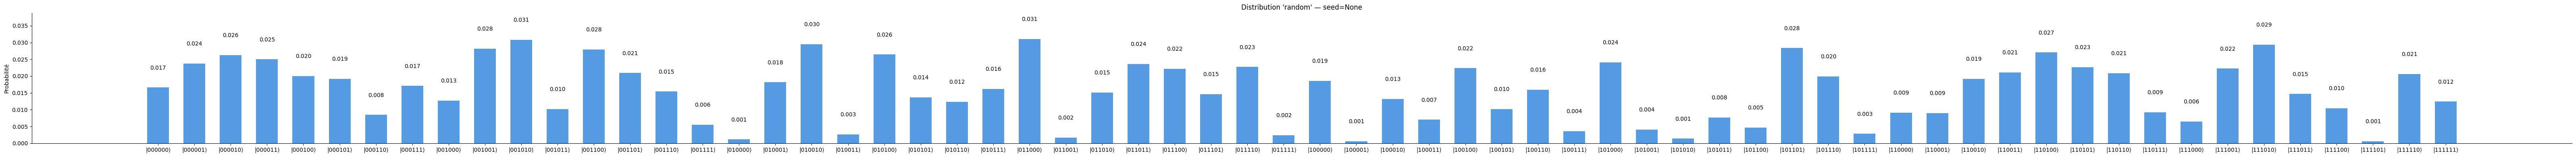

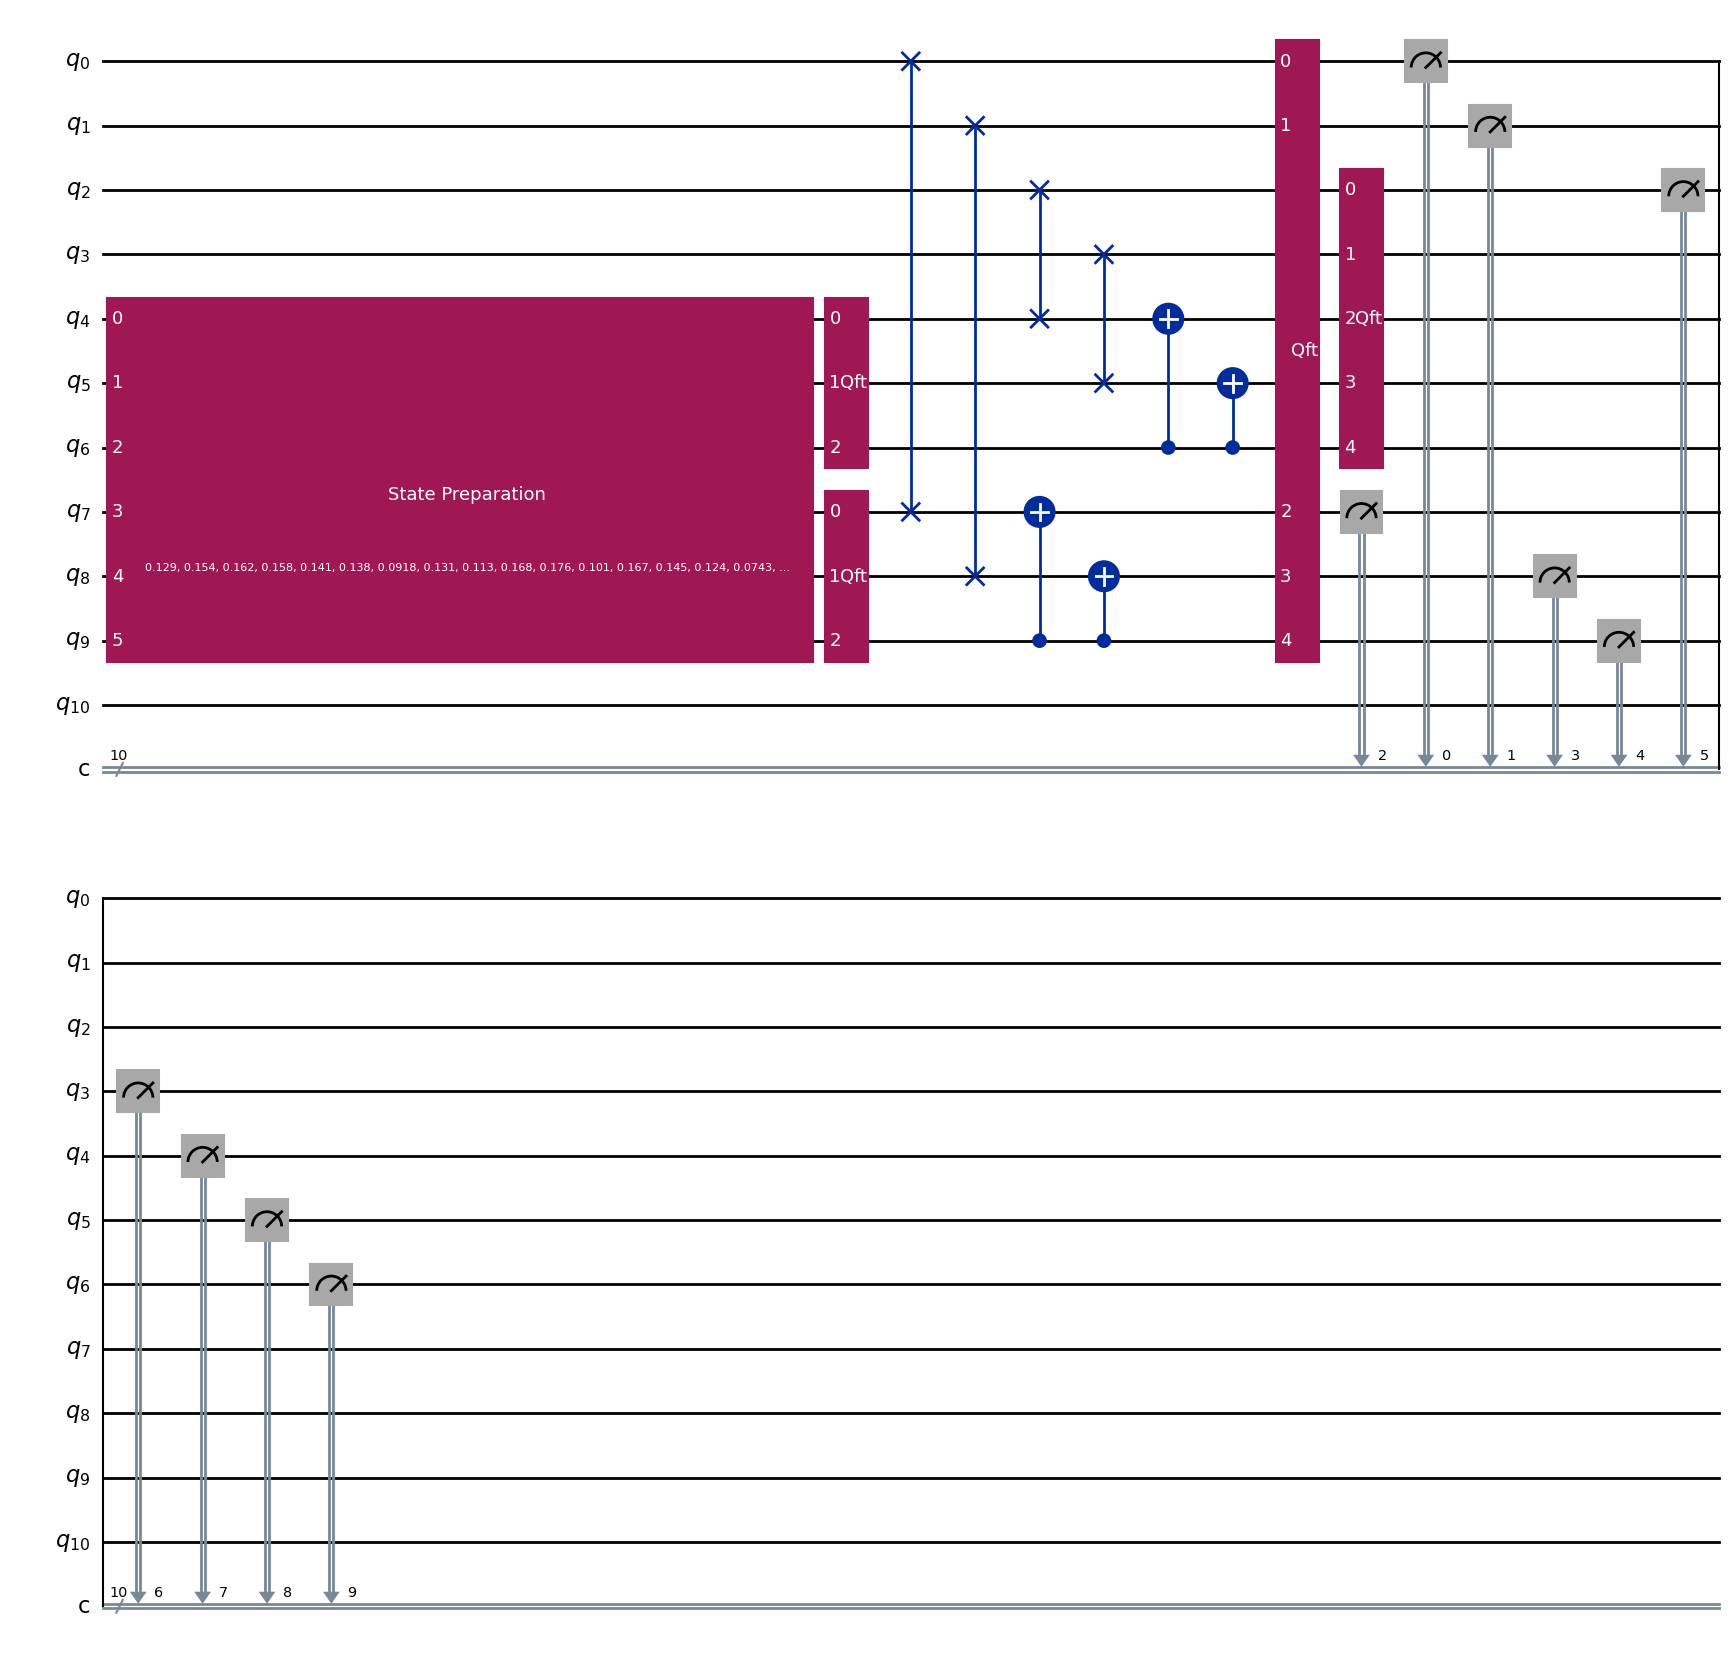

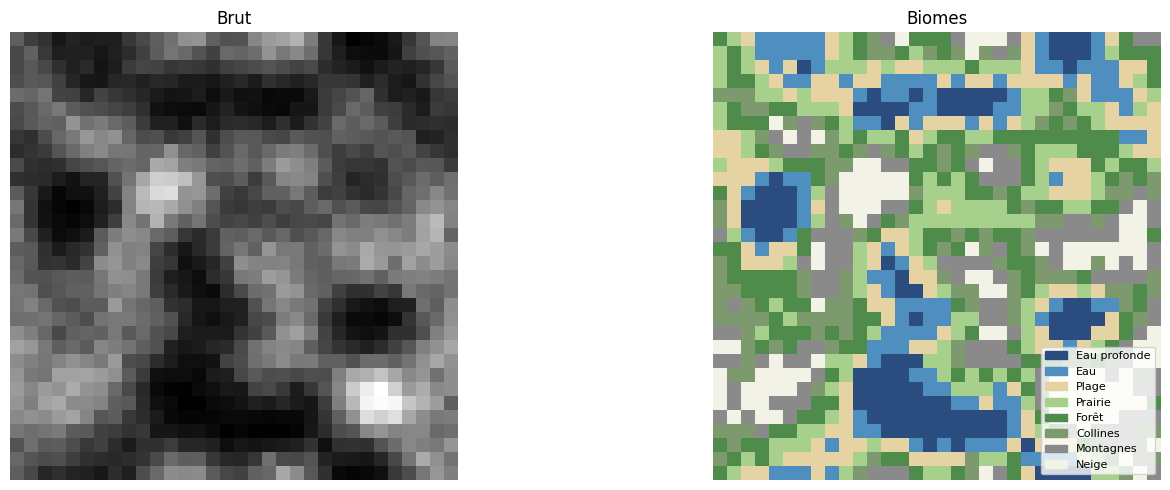

In [26]:
g = DistributionGenerator(n_states=64, dist_type="random")
g.plot()
amplitudes = np.sqrt(g.probabilities)

qc = QuantumCircuit(11, 10)

#qc.h(list(np.arange(4, 6)))
#qc.x(list(np.arange(4, 10)))



state_prep = StatePreparation(amplitudes)
qc.append(state_prep, list(np.arange(4, 10)))

qft1a = QFTGate(3)
qft1b = QFTGate(3)

qc.append(qft1a, list(np.arange(4,7)))
qc.append(qft1b, list(np.arange(7,10)))

qc.swap(0, 7)
qc.swap(1, 8)

qc.cx(9,7)
qc.cx(9,8)

qc.swap(2, 4)
qc.swap(3, 5)

qc.cx(6,4)
qc.cx(6,5)

qft2a = QFTGate(5)
qft2b = QFTGate(5)



tbl = [0,1,7,8,9,2,3,4,5,6]

qc.append(qft2a, tbl[:5])
qc.append(qft2a, tbl[-5:])



qc.measure([0,1,7,8,9,2,3,4,5,6], list(np.arange(0,10)))

display(qc.draw(output="mpl"))


simulator = AerSimulator()
shots = 50_000

transpiled = transpile(qc, simulator)
job = simulator.run(transpiled, shots=shots)
counts = job.result().get_counts()




table = np.zeros((32,32))

for bitstring, count in counts.items():
    x = int(bitstring[:5],2)
    y = int(bitstring[-5:],2)
    table[x][y] = count / 50_000





def plot_2d(noise_map: np.ndarray):
    smoothed = noise_map

    # normalisation
    smoothed = (smoothed - smoothed.min()) / (smoothed.max() - smoothed.min())

    # 7 seuils → 8 zones
    q = np.quantile(smoothed, [0.10, 0.22, 0.35, 0.50, 0.65, 0.78, 0.90])

    biome = np.digitize(smoothed, q)

    biome_colors = [
        "#2b4c7e",  # eau profonde
        "#4f8fbf",  # eau
        "#e6d3a3",  # plage
        "#a7d08c",  # prairie
        "#4f8b4a",  # forêt
        "#7c9a6d",  # collines
        "#8a8a8a",  # montagnes
        "#f2f2e6"   # neige
    ]

    biome_labels = [
        "Eau profonde",
        "Eau",
        "Plage",
        "Prairie",
        "Forêt",
        "Collines",
        "Montagnes",
        "Neige"
    ]

    cmap = ListedColormap(biome_colors)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].imshow(noise_map, cmap='gray')
    axes[0].set_title("Brut")
    axes[0].axis('off')



    im = axes[1].imshow(biome, cmap=cmap, vmin=0, vmax=7)
    axes[1].set_title("Biomes")
    axes[1].axis('off')

    patches = [plt.Rectangle((0, 0), 1, 1, color=biome_colors[i]) for i in range(8)]
    axes[1].legend(patches, biome_labels, loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_2d(table)


